# Perona-Malik on vessels

This code should try the Preona-Malik approach for edge enchansing diffusion on a vesselnes picture. See this [paper](http://ieeexplore.ieee.org/document/56205/) for reference.

We will consider the following anistropic diffusion equation:
$$I_t = div (c(x, y, t) \nabla I) = c(x, y ,t) \Delta I +  \nabla c \cdot \nabla I$$
With $I_0$ denoting the original Image.

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import skimage.io as io

To compute the gradients we compute a gradient for every cardinal direction, like suggested by Perona-Malik. This is implemented as a convolution.

In [2]:
nabla_N = np.array([[0, 1, 0], [0, -1, 0], [0, 0, 0]])  # north
nabla_S = np.array([[0, 0, 0], [0, -1, 0], [0, 1, 0]])  # south
nabla_E = np.array([[0, 0, 0], [0, -1, 1], [0, 0, 0]])  # east
nabla_W = np.array([[0, 0, 0], [1, -1, 0], [0, 0, 0]])  # west


def get_update(img, g):
    # convolve image with gradients
    I_N = convolve2d(img, nabla_N, mode='same', boundary='fill', fillvalue=0)
    I_S = convolve2d(img, nabla_S, mode='same', boundary='fill', fillvalue=0)
    I_E = convolve2d(img, nabla_E, mode='same', boundary='fill', fillvalue=0)
    I_W = convolve2d(img, nabla_W, mode='same', boundary='fill', fillvalue=0)

    # compute the gradient magnitude
    G = np.sqrt(I_N**2 + I_S**2 + I_E**2 + I_W**2)

    # compute the 90th percentile of the gradient magnitude
    K = np.percentile(G, 90)

    c_N = g(I_N, K, 'N')
    c_S = g(I_S, K, 'S')
    c_E = g(I_E, K, 'E')
    c_W = g(I_W, K, 'W')

    return c_N*I_N + c_S*I_S + c_E*I_E + c_W*I_W

In [3]:
def perona_malik(max_iter: int, step_size: float, img, g):
    img = img.copy()
    
    for _ in range(max_iter):
        img += step_size * get_update(img, g)

    return img

In [4]:
def noise(img, sigma: float):
    return img + sigma * np.random.randn(*img.shape)

In [5]:
def plot_perona_malik(max_iter: int, step_size: float, img, g, title: str, nois_sigma: float = 0.1):
    noisy_img = noise(img, 0.1)
    
    smoothed_img = perona_malik(max_iter, step_size, noisy_img, g)

    # make three subplots
    _, ax = plt.subplots(1, 3, figsize=(15, 5))

    # plot original image
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title(f'Original Image: {title}')

    # plot noisy image
    ax[1].imshow(noisy_img, cmap='gray')
    ax[1].set_title(f'Noisy Image: {title}')

    # plot smoothed image
    ax[2].imshow(smoothed_img, cmap='gray')
    ax[2].set_title(f'Smoothed Image: {title}')

    plt.show()

To enhance the edges we define in `cc_edge_enhancing` $$c \coloneqq g (|| \nabla I ||)$$ $$g(x) \coloneqq \frac{C}{1+(\frac{x}{K})^{1+\alpha}}$$

As suggested by Perona-Malik we define `cc_edge_enhancing_boundary` the same formula, just with adiabatic boundary conditions (the conduction coefficient is set to zero at the boundaries).

For comparison we define in `cc_gaussian` $c(|| \nabla I ||) = || \nabla I ||$

In [6]:
def cc_edge_enhancing(nabla, K, direction):
    # nabla being a nxn matrix of a discrete gradient
    # aplly the edge enhancing function to the gradient
    return 1/(1+(np.abs(nabla)/K)**2)   # for edge enhancing


def cc_gaussian(nabla, K, direction):
    return np.abs(nabla) # for gaussian smoothing


def cc_edge_enhancing_boundary(nabla, K, direction):
    # nabla being a nxn matrix of a discrete gradient
    # aplly the edge enhancing function to the gradient
    temp = 1/(1+(np.abs(nabla)/K)**2)   # for edge enhancing

    match direction:
        case 'N':
            # set the north boundary to zero
            temp[0, :] = 0
        case 'S':
            # set the south boundary to zero
            temp[-1, :] = 0
        case 'E':
            # set the east boundary to zero
            temp[:, -1] = 0
        case 'W':
            # set the west boundary to zero
            temp[:, 0] = 0

    return temp

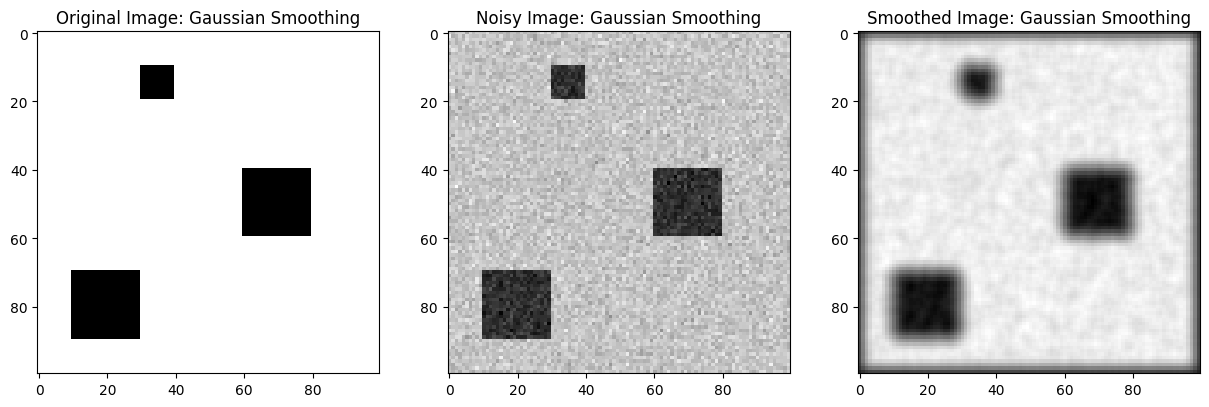

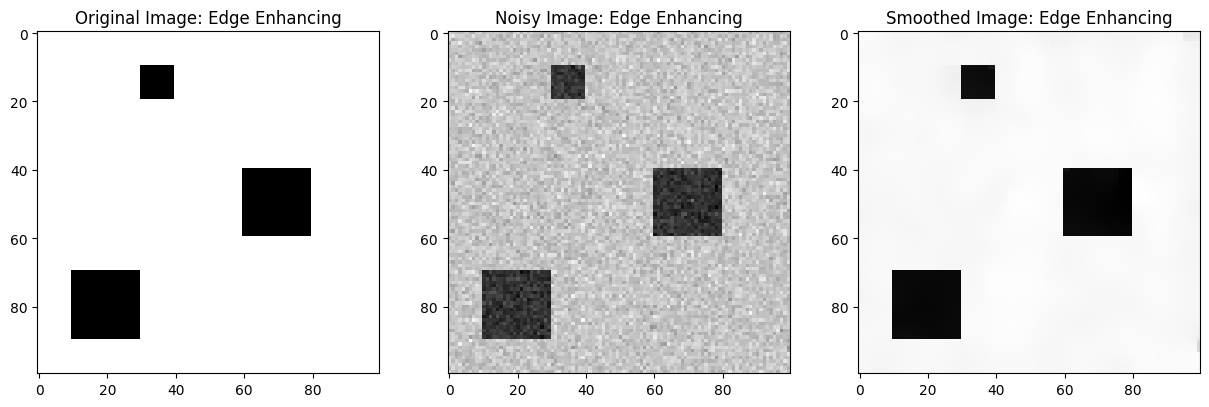

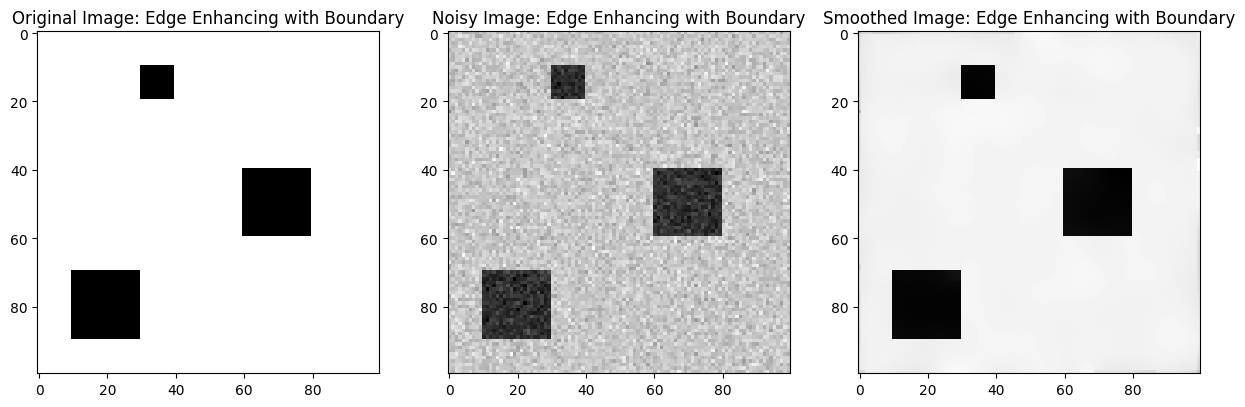

In [7]:
img = np.zeros((100, 100))

# draw some empty rectangles

img[10:20, 30:40] = 1
img[40:60, 60:80] = 1
img[70:90, 10:30] = 1

img = 1 - img

plot_perona_malik(100, 0.1, img, cc_gaussian, 'Gaussian Smoothing')
plot_perona_malik(100, 0.1, img, cc_edge_enhancing, 'Edge Enhancing')
plot_perona_malik(100, 0.1, img, cc_edge_enhancing_boundary, 'Edge Enhancing with Boundary')

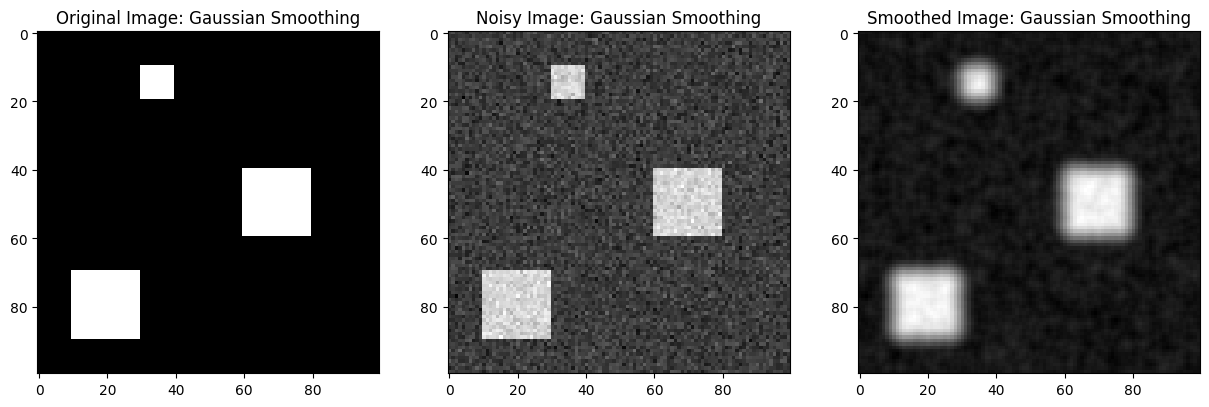

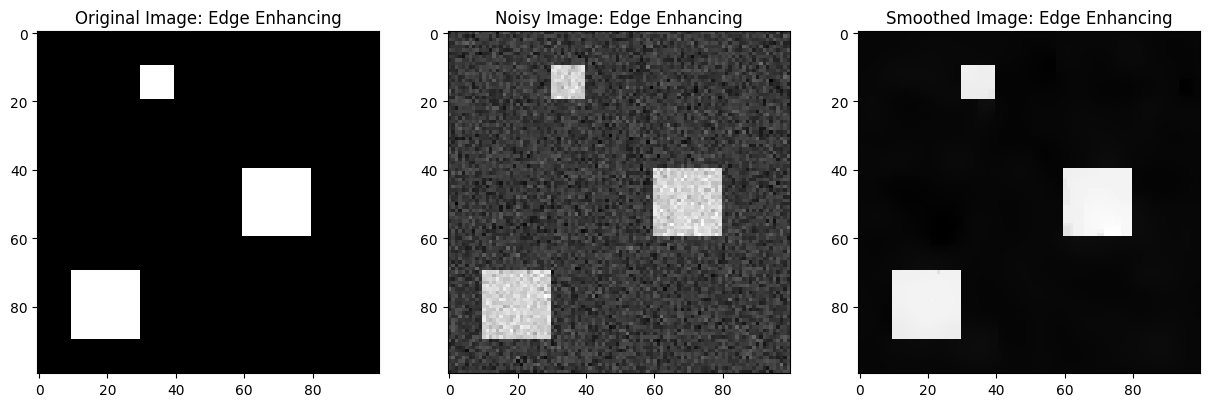

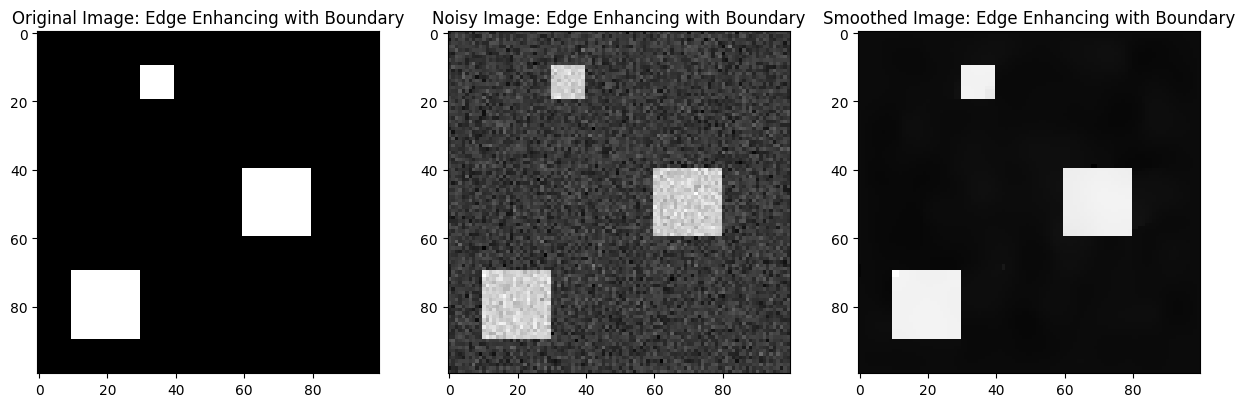

In [8]:
img = np.zeros((100, 100))

# draw some empty rectangles

img[10:20, 30:40] = 1
img[40:60, 60:80] = 1
img[70:90, 10:30] = 1

plot_perona_malik(100, 0.1, img, cc_gaussian, 'Gaussian Smoothing')
plot_perona_malik(100, 0.1, img, cc_edge_enhancing, 'Edge Enhancing')
plot_perona_malik(100, 0.1, img, cc_edge_enhancing_boundary, 'Edge Enhancing with Boundary')

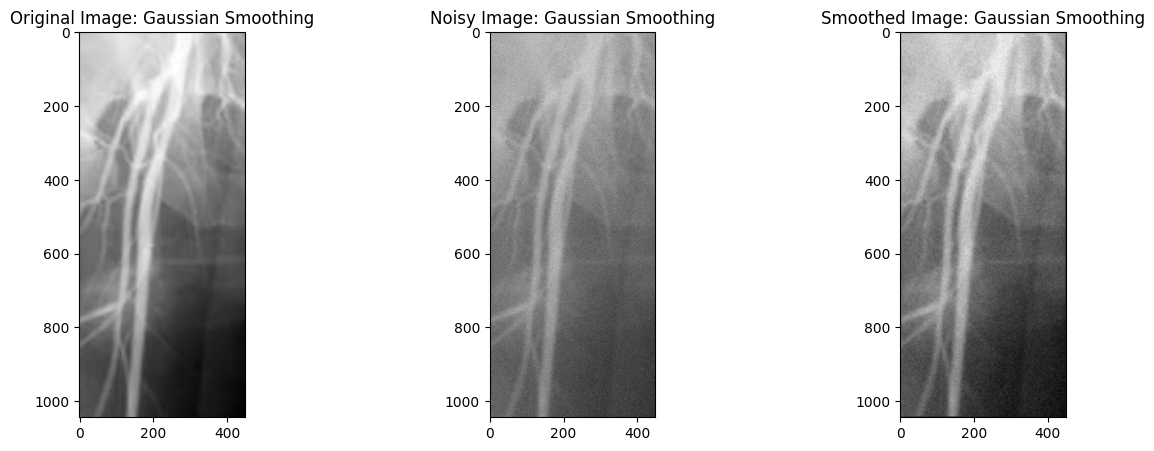

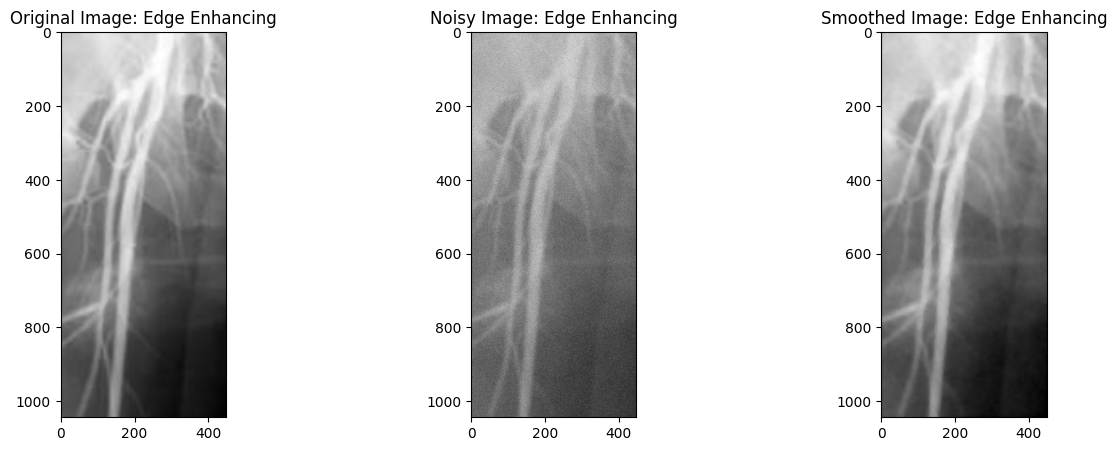

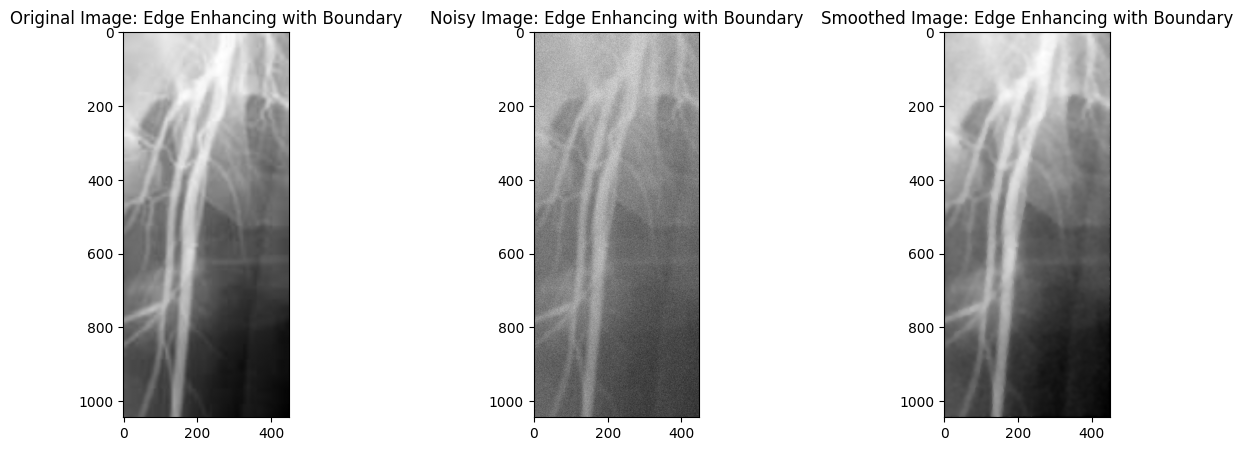

In [9]:
img = io.imread('vessels.png', as_gray=True)

plot_perona_malik(100, 0.1, img, cc_gaussian, 'Gaussian Smoothing')
plot_perona_malik(100, 0.1, img, cc_edge_enhancing, 'Edge Enhancing')
plot_perona_malik(100, 0.1, img, cc_edge_enhancing_boundary, 'Edge Enhancing with Boundary')